#### Question 01 ####

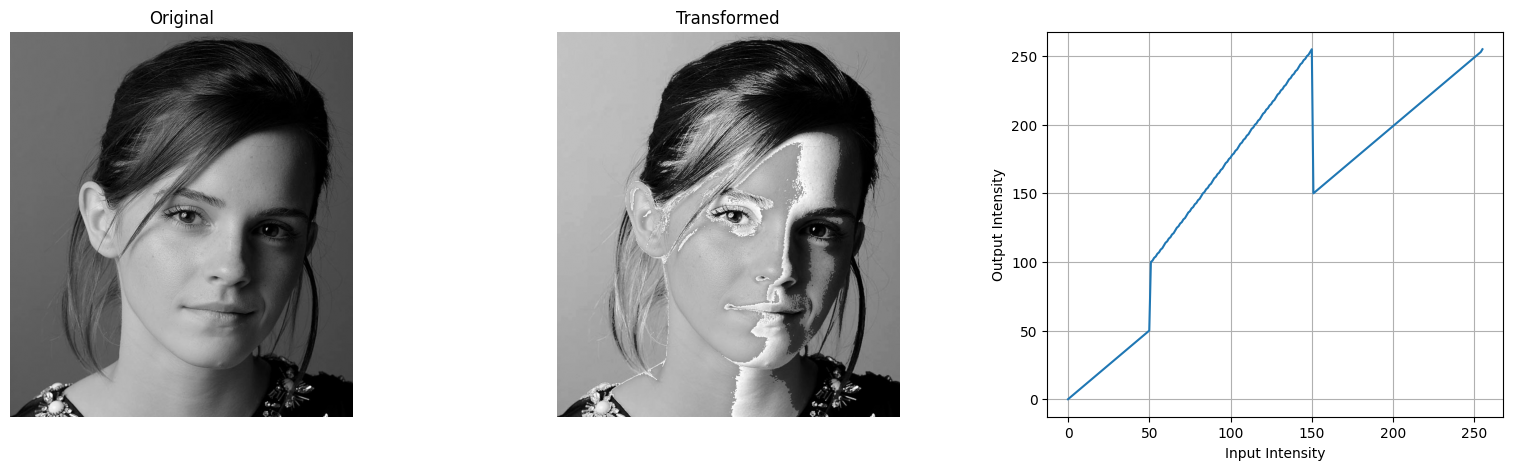

<Figure size 640x480 with 0 Axes>

In [80]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


t1 = np.linspace(0, 50, 51).astype('uint8')
t2 = np.linspace(100 , 255, 100).astype('uint8')
t3 = np.linspace(150, 255, 105).astype('uint8')

transform = np.concatenate((t1, t2), axis= 0).astype('uint8')
transform = np.concatenate((transform, t3), axis = 0).astype('uint8')


original = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
transformed = cv.LUT(original, transform)

plt.figure(figsize=(20,5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 3, 2)
plt.title("Transformed")
plt.imshow(transformed, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(np.arange(256), transform)
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()


plt.tight_layout()
plt.show()

#### Question 02 ####

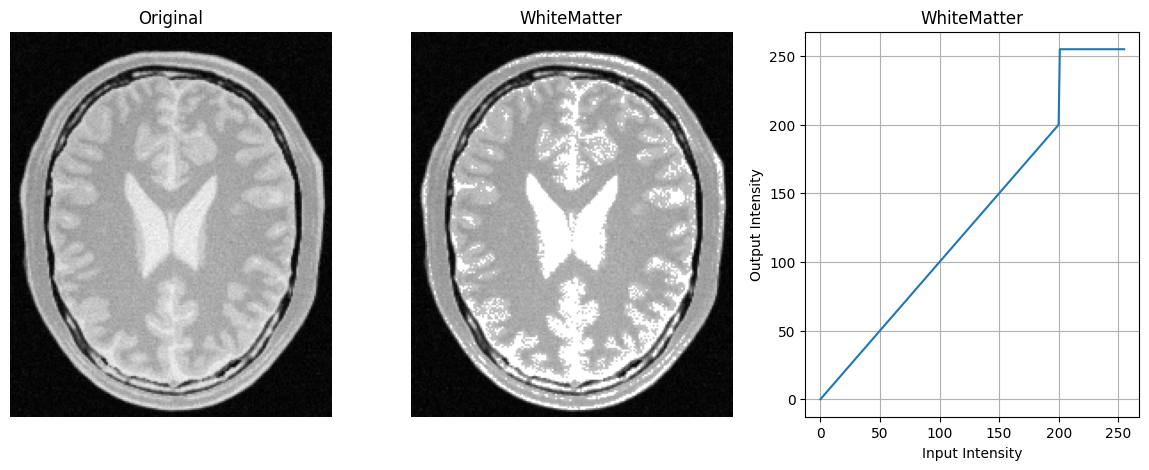

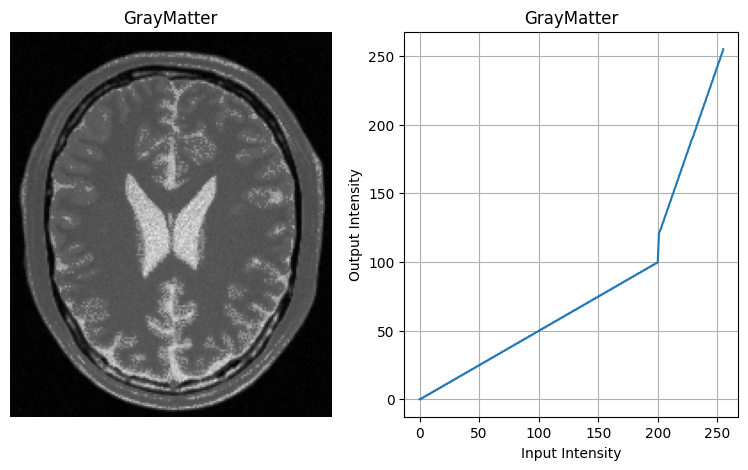

<Figure size 640x480 with 0 Axes>

In [81]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


t1 = np.linspace(0, 200, 201).astype('uint8')    # Enhance the white matters 
t2 = np.linspace(255 , 255, 55).astype('uint8')

t3 = np.linspace(0, 100, 201).astype('uint8')    # Enhance the gray matters
t4 = np.linspace(121 , 255, 55).astype('uint8')

transform_1 = np.concatenate((t1, t2), axis= 0).astype('uint8')

transform_2 = np.concatenate((t3, t4), axis= 0).astype('uint8')


original = cv.imread('images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)
GrayMatter = cv.LUT(original, transform_2)

WhiteMatter = cv.LUT(original,transform_1)

plt.figure(figsize=(25,5))
plt.subplot(1, 5, 1)
plt.title("Original")
plt.imshow(original, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 5, 2)
plt.title("WhiteMatter")
plt.imshow(WhiteMatter, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 5, 3)
plt.plot(np.arange(256), transform_1)
plt.title("WhiteMatter")
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()

plt.figure(figsize=(25,5))
plt.subplot(1, 5, 4)
plt.title("GrayMatter")
plt.imshow(GrayMatter, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 5, 5)
plt.plot(np.arange(256), transform_2)
plt.title("GrayMatter")
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()



plt.tight_layout()
plt.show()

#### Question 03 ####

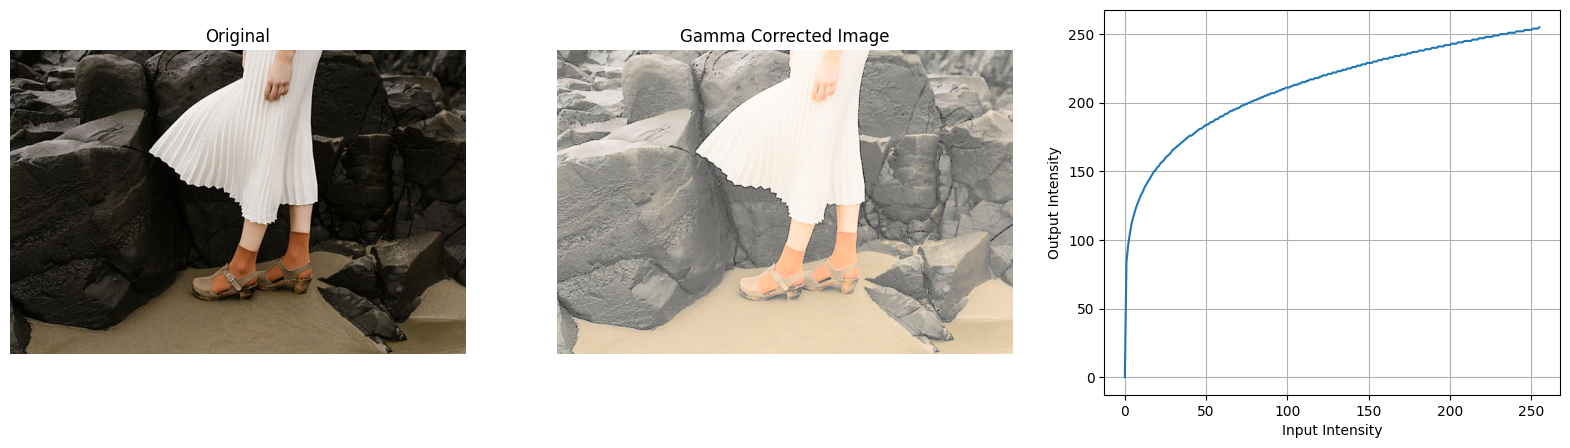

<Figure size 640x480 with 0 Axes>

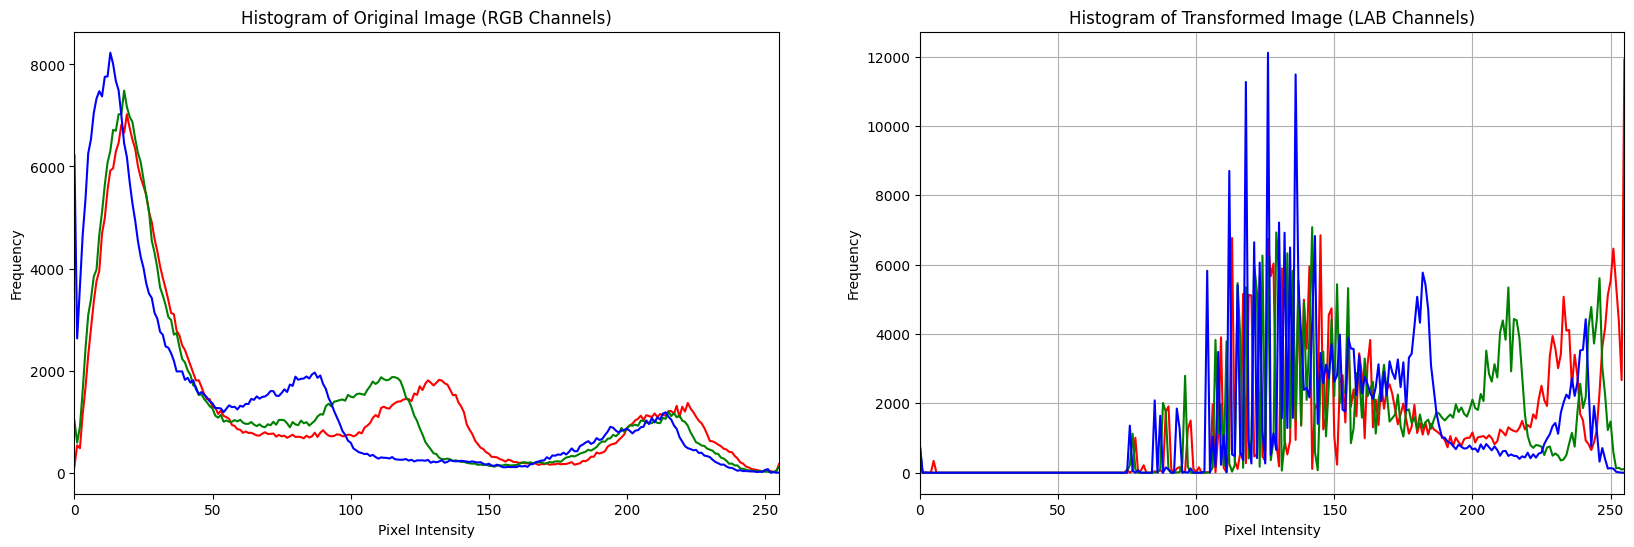

In [82]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

gamma = 0.2
original = cv.imread('images/highlights_and_shadows.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)
lab = cv.cvtColor(original, cv.COLOR_RGB2LAB)
L, a, b = cv.split(lab)
transform = np.array([(i/255)**(gamma)*255 for i in np.arange(0,256)]).astype('uint8')
L_transformed = cv.LUT(L, transform)
transformed = cv.merge([L_transformed,a,b])

corrected_image = cv.cvtColor(transformed, cv.COLOR_LAB2RGB)

plt.figure(figsize=(20,5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 3, 2)
plt.title("Gamma Corrected Image")
plt.imshow(corrected_image, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(np.arange(256), transform)
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()

plt.tight_layout()
plt.show()


colorsbgr = ('r', 'g', 'b')
colorslab = ('l', 'a', 'b')

plt.figure(figsize=(20, 6))
plt.subplot(1,2,1)
plt.title('Histogram of Original Image (RGB Channels)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

for i, col in enumerate(colorsbgr):
    hist = cv.calcHist([original], [i], None, [256], (0,256))
    plt.plot(hist, color = col)
    plt.xlim([0,255])

plt.subplot(1,2,2)
plt.title('Histogram of Transformed Image (LAB Channels)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

for i, col in enumerate(colorsbgr):
    hist = cv.calcHist([corrected_image], [i], None, [256], (0,256))
    plt.plot(hist, color = col)
    plt.xlim([0,255])

plt.grid(True)
plt.show()

#### Question 4 ####
##### a = 0.9 #####

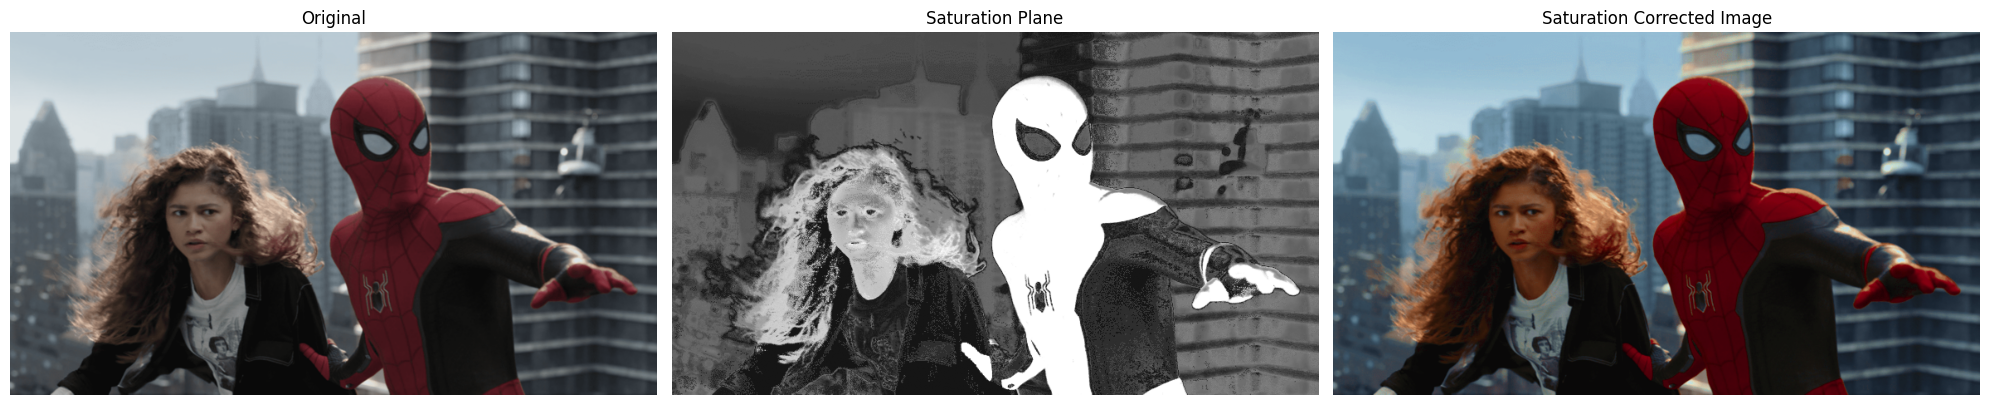

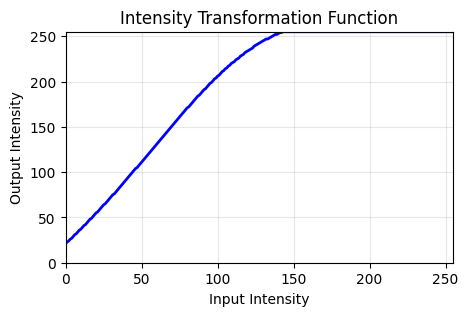

In [83]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('images/spider.png')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(original, cv.COLOR_RGB2HSV)
h, s, v = cv.split(hsv)

a = 0.9
sigma = 70
transform = np.array([
    min(i + a * 128 * np.exp(-((i - 128)**2 / (2 * sigma**2))), 255)
    for i in range(256)
]).astype('uint8')

s_transformed = cv.LUT(s, transform)
transformed = cv.merge([h, s_transformed, v])
corrected_image = cv.cvtColor(transformed, cv.COLOR_HSV2RGB)

plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Saturation Plane")
plt.imshow(s_transformed, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Saturation Corrected Image")
plt.imshow(corrected_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()


plt.figure(figsize=(5, 3))
input_values = np.arange(256)
output_values = transform
plt.plot(input_values, output_values, 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Intensity Transformation Function')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.show()


#### Question 05 ####

In [94]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('images/shells.tif', cv.IMREAD_GRAYSCALE)



#### Question 06 ####

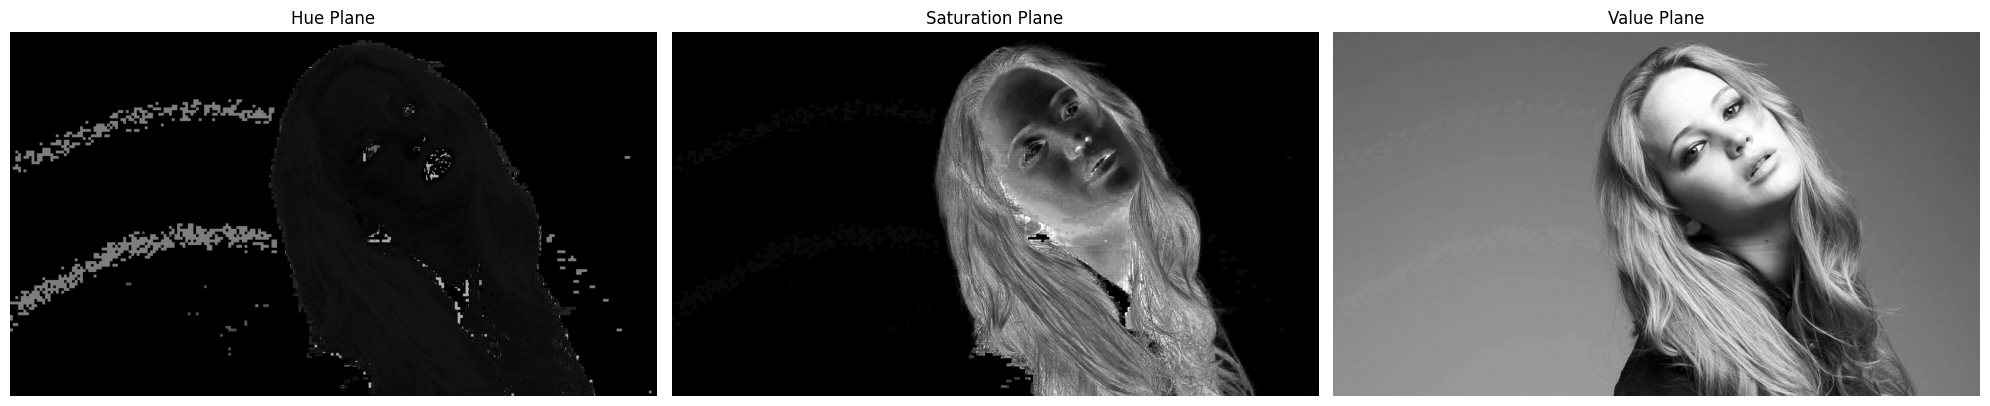

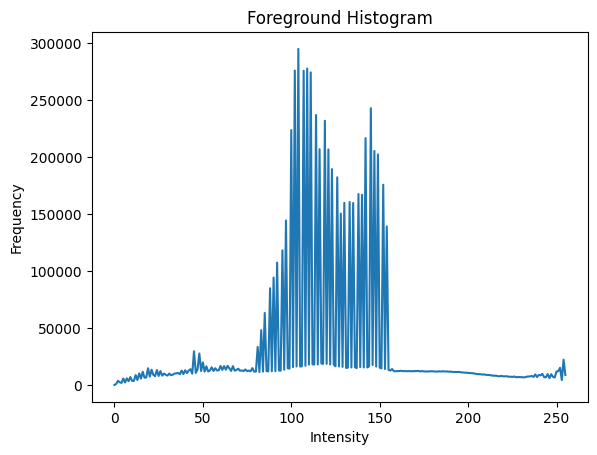

[1.480000e+02 1.189000e+03 4.966000e+03 7.339000e+03 9.292000e+03
 1.504800e+04 1.734300e+04 2.324800e+04 2.671000e+04 3.377100e+04
 3.740300e+04 4.115800e+04 4.991300e+04 5.439900e+04 6.467500e+04
 7.037500e+04 8.209400e+04 8.857700e+04 9.529700e+04 1.100930e+05
 1.174430e+05 1.309590e+05 1.399100e+05 1.477630e+05 1.609220e+05
 1.689500e+05 1.812100e+05 1.894960e+05 1.996170e+05 2.086580e+05
 2.170010e+05 2.271180e+05 2.357550e+05 2.449170e+05 2.550610e+05
 2.653470e+05 2.759840e+05 2.855030e+05 2.982380e+05 3.079020e+05
 3.209470e+05 3.314530e+05 3.442540e+05 3.582190e+05 3.681990e+05
 3.978570e+05 4.085330e+05 4.223750e+05 4.500810e+05 4.624470e+05
 4.823630e+05 4.941640e+05 5.106290e+05 5.225370e+05 5.353180e+05
 5.509080e+05 5.633070e+05 5.780810e+05 5.908630e+05 6.038890e+05
 6.206500e+05 6.339750e+05 6.506330e+05 6.641810e+05 6.810770e+05
 6.957070e+05 7.081450e+05 7.248030e+05 7.374180e+05 7.507320e+05
 7.651490e+05 7.777690e+05 7.905770e+05 8.028630e+05 8.165560e+05
 8.288420e

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('images/jeniffer.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(original, cv.COLOR_RGB2HSV)
h, s, v = cv.split(hsv)

plt.figure(figsize=(20,5))
plt.subplot(1, 3, 1)
plt.title("Hue Plane")
plt.imshow(h, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Saturation Plane")
plt.imshow(s, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Value Plane")
plt.imshow(v, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

_, mask = cv.threshold(v,0,255,cv.THRESH_BINARY)
foreground = cv.bitwise_and(original, original, mask=mask)
hist = cv.calcHist([original],[0],mask,[256],[0,256])

plt.plot(hist)
plt.title("Foreground Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

# Flatten and calculate CDF
hist_flatten = hist.flatten()
cdf = np.cumsum(hist_flatten)
print(cdf)